In this notebook, we present our preliminary analysis on the selection of the number of clusters using the k-means algorithm. This decision was guided not only by statistical evidence but also by clinical reasoning regarding the practicality of the resulting subphenotypes.

Additionally, we present results confirming that k-means offers the most robust solution when compared to other clustering algorithms and variations in clustering hyperparameters.

In [1]:
library(yaml)
library(dplyr)
library(ggplot2)
library(reshape2)
library(ComplexHeatmap)
library(circlize)
library(umap)
library(tidyverse)
library(fossil) # compute rand.index

Sys.setlocale("LC_ALL", "en_US.UTF-8") # for the plus_minus character
setwd("../")
source("scripts/procrustes_analysis_utils.R")
source("scripts/cluster_selection_utils.R")
source('scripts/utils.R')


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

[1] "LC_CTYPE=en_US.UTF-8;LC_NUMERIC=C;LC_TIME=en_US.UTF-8;LC_COLLATE=en_US.UTF-8;LC_MONETARY=en_US.UTF-8;LC_MESSAGES=en_US.UTF-8;LC_PAPER=en_US.UTF-8;LC_NAME=C;LC_ADDRESS=C;LC_TELEPHONE=C;LC_MEASUREMENT=en_US.UTF-8;LC_IDENTIFICATION=C"

Loading required package: cluster


Attaching package: ‘cluster’


The following object is masked from ‘package:maps’:

    votes.repub


Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa


Attaching package: ‘plotly’


The following object is masked from ‘package:ComplexHeatmap’:

    add_heatmap


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout




Using virtual environment '/home/ines/.virtualenvs/r-reticulate' ...


+ /home/ines/.virtualenvs/r-reticulate/bin/python -m pip install --upgrade --no-user 'kaleido==0.2.1'



Using virtual environment '/home/ines/.virtualenvs/r-reticulate' ...


+ /home/ines/.virtualenvs/r-reticulate/bin/python -m pip install --upgrade --no-user 'kaleido==0.2.1'



In [2]:
# Create a directory for the figures
output_path <- "outputs/clustering_analysis/clustering_selection/"
if (!dir.exists(output_path)) {
  dir.create(output_path)
}

In [3]:
# Load the configuration file
config <- yaml::yaml.load_file("config.yml")
# Load the landmark coordinates data
df_coordinates <- read.csv(config$dataset$landmark_coordinates, check.names = FALSE, row.names = 1)
cluster_palette <- config$colors$cluster

In [4]:
# Perform Generalized Procrustes Analysis
object_generalized_procrustes <- generalized_procrustes(df_coordinates)
procrutes_residuals <- object_generalized_procrustes$tan

# Select the number of clusters (k)

Based on the following results and clinical reasoning—particularly the practical relevance of the subphenotypes—k was set to six. Our data could be grouped into six clinically meaningful subphenotypes.

## Elbow Method

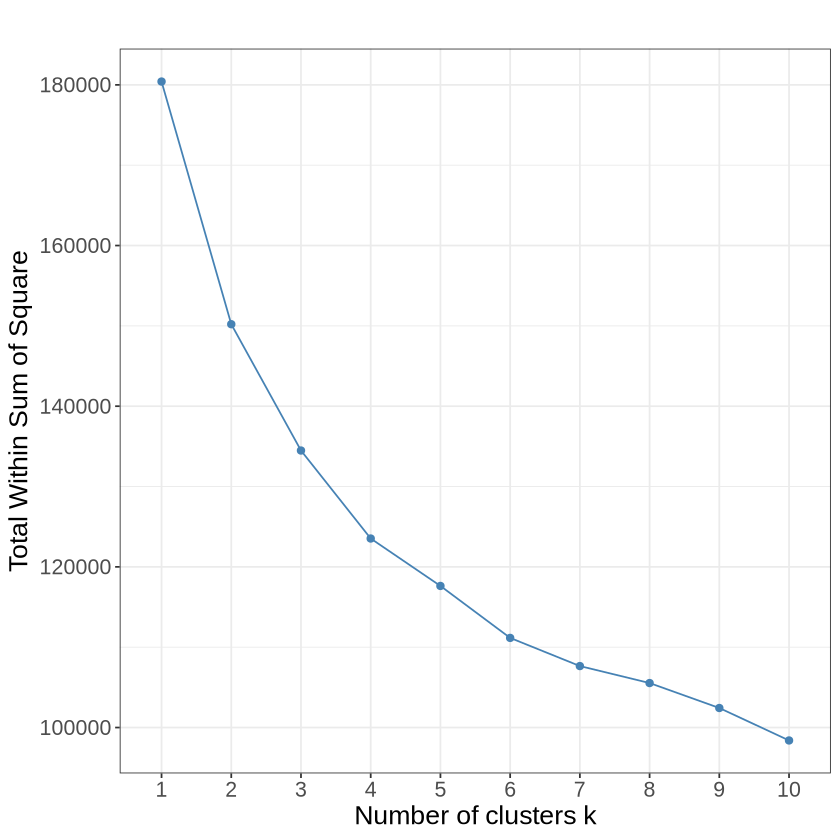

In [5]:
options(repr.plot.width = 7, repr.plot.height = 7)
# save plot
#pdf(paste0(output_path, "elbow.pdf"), width = 7, height = 4)

fviz_nbclust(object_generalized_procrustes$tan, kmeans, method = "wss") +
  theme_bw() +
  ggtitle("") +  # Remove the title
  theme(text = element_text(size = 16))
#dev.off()

## Average Silhouette Width

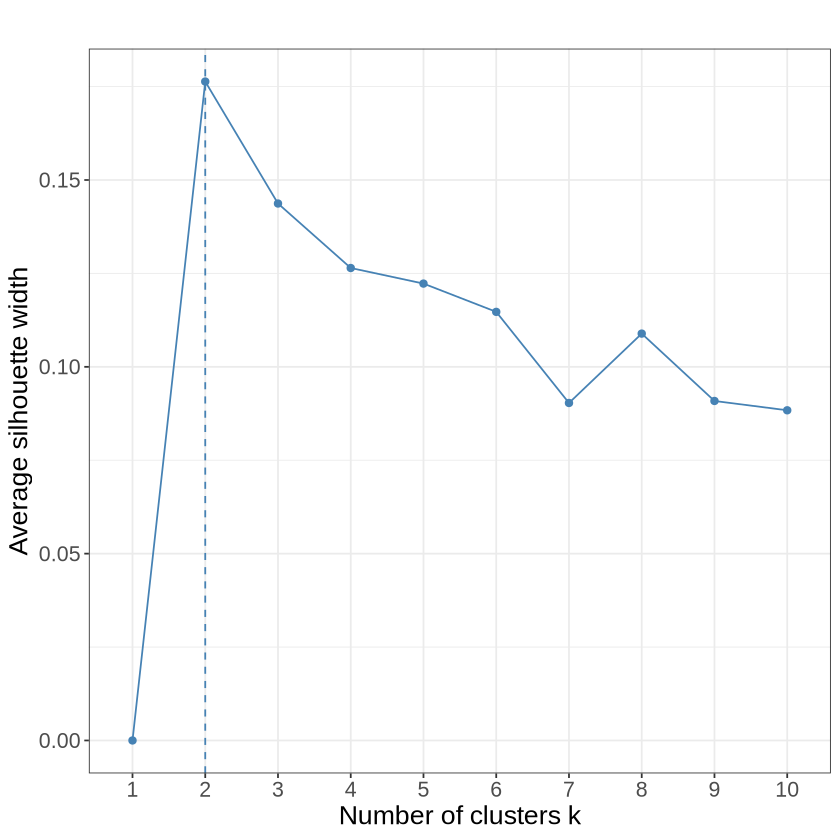

In [6]:
#pdf(paste0(output_path, "average_silhouette.pdf"), width = 7, height = 4)
fviz_nbclust(object_generalized_procrustes$tan, kmeans, method = "silhouette") +
  theme_bw() +
  ggtitle("") +
  theme(text = element_text(size = 16))
#dev.off()

Balancing some clinical reasoning and the presented statistics a solution of **six** clusters can effectivelly stractify the presented sciii cohort.

# Compare solutions of different clustering algorithms

(considering k=6)


We first examined several clustering metrics and ranked the models based on their top-performing scores. Next, we compared the clustering solutions by mapping them using the Jaccard coefficient. While several clustering algorithms produced equivalent solutions, some—particularly those with k = 6—resulted in clusters with very few patients (n < 5), which we considered ineffective or not meaningful. Considering the clustering quality and distribution of patients across clusters, we selected K-means as the final clustering algorithm. Its solution provided an effective and balanced distribution of patients among the clusters.

In [7]:
# Perform clustering evaluation for different methods and metrics on the procrustes residuals
cluster_evaluation_results <- evaluate_clustering_types(procrutes_residuals)
head(cluster_evaluation_results$df_metrics)

,hc_metric,fun_cluster,k,connectivity,dunn,silhouette,average_between,average_within,entropy,persongamma,wb_ratio,gini_index,max_perc_membership,min_perc_membership,median_perc_membership,check_balance_threshold,min_max_membership_ratio
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
1,euclidean,kmeans,6,687.51182,0.1345622,0.10443311,23.65423,18.01373,1.75730388,0.3566330,0.7615438,0.1315522,23.20611,8.8549618,16.9465649,TRUE,0.381578947
2,euclidean,pam,6,835.70213,0.1324035,0.08321596,23.65566,18.36538,1.72946689,0.3437189,0.7763629,0.1956743,27.93893,10.0763359,14.5801527,TRUE,0.360655738
3,euclidean,hclust-single,6,19.12146,0.3378952,0.19777088,35.85462,22.39273,0.05710541,0.2571839,0.6245423,0.8256997,99.23664,0.1526718,0.1526718,FALSE,0.001538462
4,euclidean,hclust-complete,6,582.54426,0.1606491,0.05117572,24.35839,19.83224,1.16944605,0.3304015,0.8141852,0.5849873,58.77863,0.4580153,6.7175573,TRUE,0.007792208
5,euclidean,hclust-average,6,149.39087,0.2118583,0.18993762,28.93066,20.91366,0.46797112,0.5167696,0.7228893,0.7758270,88.24427,0.1526718,1.9083969,FALSE,0.001730104
6,euclidean,hclust-centroid,6,19.34539,0.3133079,0.20704584,36.13235,22.38844,0.05710541,0.2625719,0.6196230,0.8256997,99.23664,0.1526718,0.1526718,FALSE,0.001538462


## Rank methods by metric and compute average rank

In [8]:
# Compute overall rankg of clustering methods
# Define ranking direction for each column
ranking_directions <- c(
  connectivity = "min",
  dunn = "max",
  silhouette = "max",
  average_between = "max",
  average_within = "min",
  entropy = "max",
  persongamma = "max",
  wb_ratio = "min"
)

# Perform the ranking and compute an average rank
ranked_df <- cluster_evaluation_results$df_metrics %>% filter(check_balance_threshold == TRUE)

for (i in c('connectivity', 'dunn', 'silhouette', 'average_between', 'average_within', 'entropy', 'persongamma', 'wb_ratio')) {
  if (ranking_directions[i] == "min") {
    aux_metric <- ranked_df[, i]
  } else if (ranking_directions[i] == "max") {
    aux_metric <- -ranked_df[, i] # Invert the metric for ranking
  }
  ranked_df[, paste('rank', i)] <- dense_rank(aux_metric) # Rank the metric
}
# Compute the average rank and sort the dataframe
ranked_df  <- ranked_df %>% mutate(`Average Rank` = rowMeans(select(., starts_with("rank")), na.rm = TRUE)) %>% arrange(`Average Rank`)
ranked_df[1:10, ]

,hc_metric,fun_cluster,k,connectivity,dunn,silhouette,average_between,average_within,entropy,persongamma,⋯,min_max_membership_ratio,rank connectivity,rank dunn,rank silhouette,rank average_between,rank average_within,rank entropy,rank persongamma,rank wb_ratio,Average Rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>
1,euclidean,diana-single,6,475.9510,0.1583036,0.1077695,25.36468,19.38446,1.167674,0.4915114,⋯,0.004819277,1,4,1,1,8,10,1,2,3.50
2,euclidean,diana-complete,6,475.9510,0.1583036,0.1077695,25.36468,19.38446,1.167674,0.4915114,⋯,0.004819277,1,4,1,1,8,10,1,2,3.50
3,euclidean,diana-average,6,475.9510,0.1583036,0.1077695,25.36468,19.38446,1.167674,0.4915114,⋯,0.004819277,1,4,1,1,8,10,1,2,3.50
4,euclidean,diana-centroid,6,475.9510,0.1583036,0.1077695,25.36468,19.38446,1.167674,0.4915114,⋯,0.004819277,1,4,1,1,8,10,1,2,3.50
5,euclidean,diana-median,6,475.9510,0.1583036,0.1077695,25.36468,19.38446,1.167674,0.4915114,⋯,0.004819277,1,4,1,1,8,10,1,2,3.50
6,euclidean,diana-mcquitty,6,475.9510,0.1583036,0.1077695,25.36468,19.38446,1.167674,0.4915114,⋯,0.004819277,1,4,1,1,8,10,1,2,3.50
7,euclidean,diana-ward.D,6,475.9510,0.1583036,0.1077695,25.36468,19.38446,1.167674,0.4915114,⋯,0.004819277,1,4,1,1,8,10,1,2,3.50
8,euclidean,diana-ward.D2,6,475.9510,0.1583036,0.1077695,25.36468,19.38446,1.167674,0.4915114,⋯,0.004819277,1,4,1,1,8,10,1,2,3.50
9,euclidean,kmeans,6,687.5118,0.1345622,0.1044331,23.65423,18.01373,1.757304,0.3566330,⋯,0.381578947,10,9,2,11,1,1,3,1,4.75


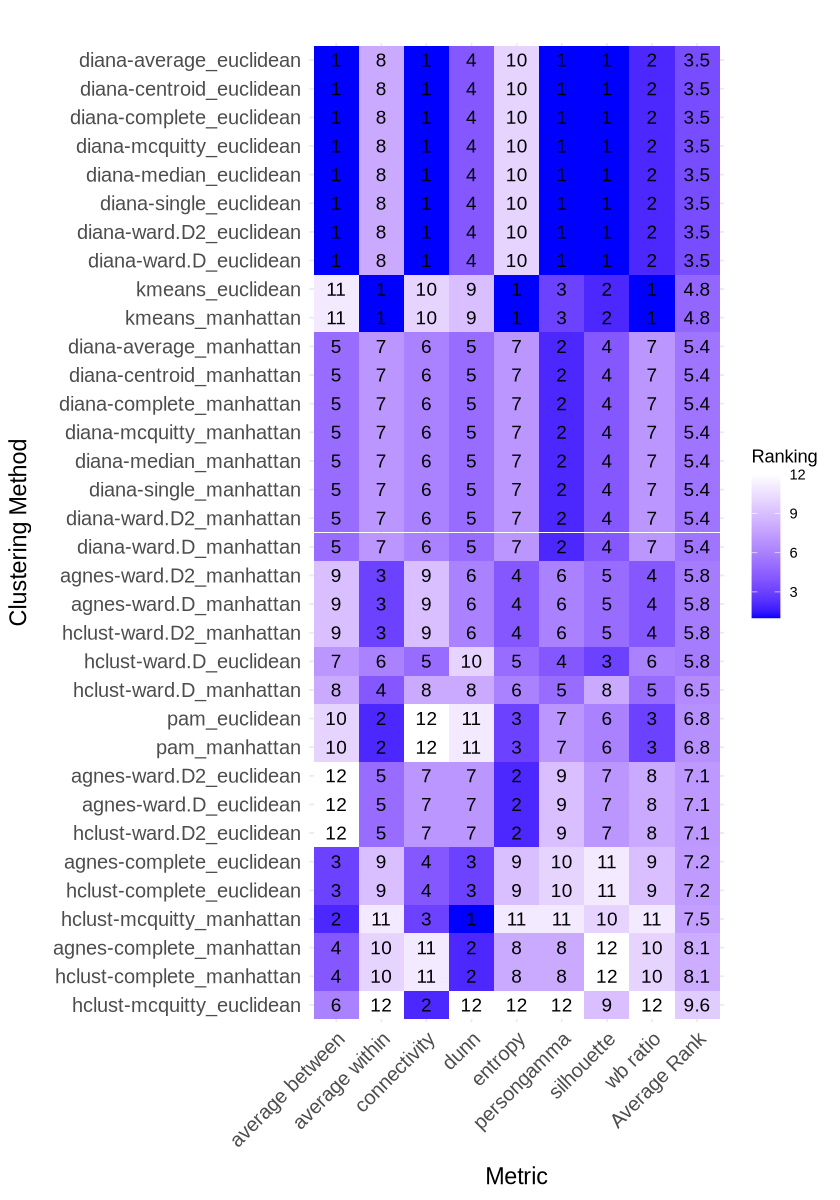

In [9]:
# Generate a heatmap of the rankings
options(repr.plot.width = 7, repr.plot.height = 10)

# Prepare the data
heatmap_data <- ranked_df %>%
  select(contains("rank"), hc_metric, fun_cluster, `Average Rank`) %>%  # Ensure Average_Rank is included
  rename_with(~ gsub("rank", "", .)) %>%  # Remove the word "rank" from the column names
  mutate(Algorithm = paste(fun_cluster, hc_metric, sep = "_")) %>%
  select(-hc_metric, -fun_cluster) %>%
  rename_with(~ gsub("_", " ", .)) %>%  # Replace underscores with spaces
  arrange(desc(`Average Rank`), desc(Algorithm)) %>%  # Arrange by Average Rank
  pivot_longer(cols = -c(Algorithm), names_to = "Metric", values_to = "Ranking")


# Create the heatmap using ggplot2
ranking_heatmap_plot <- ggplot(heatmap_data, aes(x = Metric, y = factor(Algorithm, levels = unique(Algorithm)), fill = Ranking)) +
  geom_tile() +
  geom_text(aes(label = round(Ranking, 1)), size = 4) + 
  scale_fill_gradient(low = "blue", high = "white") +  # Adjust color scale as needed
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title.x = element_text(size = 14),
    axis.title.y = element_text(size = 14),
    plot.title = element_text(size = 16, hjust = 0.5)
  ) +
  labs(title = "", x = "Metric", y = "Clustering Method")

ggsave(paste0(output_path, "heatmap_ranking.pdf"), plot = ranking_heatmap_plot, width = 7, height = 10, dpi = 300)
ranking_heatmap_plot

## Mapping, Matching between cluster solutions

Different clustering algorithms produce varying clustering solutions. To better compare them, we first mapped the clusters and then aligned them based on similarity. This alignment was done by maximizing the Jaccard coefficient.

In [10]:
# Map and Match the obtained clusters (against the kmeans_euclidean clusters)
df_cluster_mapped <- cluster_evaluation_results$df_clusters
for (i in colnames(cluster_evaluation_results$df_clusters)){
    if (i != 'kmeans_euclidean') {
        # Compute mapping
        cluster_map <- cluster_matching(cluster_to = setNames(df_cluster_mapped[, 'kmeans_euclidean'], rownames(df_cluster_mapped)) , cluster_from = setNames(df_cluster_mapped[, i], rownames(df_cluster_mapped)) , verbose = FALSE)
        # Transform the clusters
        clusters <- cluster_mapping(setNames(df_cluster_mapped[, i], rownames(df_cluster_mapped)), cluster_map$map)
        df_cluster_mapped[, i] <- clusters # update the clusters
    }
}
head(df_cluster_mapped)

,kmeans_euclidean,pam_euclidean,hclust_single_euclidean,hclust_complete_euclidean,hclust_average_euclidean,hclust_centroid_euclidean,hclust_median_euclidean,hclust_mcquitty_euclidean,hclust_ward.D_euclidean,hclust_ward.D2_euclidean,⋯,agnes_ward.D_manhattan,agnes_ward.D2_manhattan,diana_single_manhattan,diana_complete_manhattan,diana_average_manhattan,diana_centroid_manhattan,diana_median_manhattan,diana_mcquitty_manhattan,diana_ward.D_manhattan,diana_ward.D2_manhattan
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CT-001,3,3,1,4,1,1,1,5,4,5,⋯,3,3,1,1,1,1,1,1,1,1
CT-002,5,6,1,4,1,1,1,5,6,5,⋯,4,4,4,4,4,4,4,4,4,4
CT-003,3,4,1,4,1,1,1,5,3,5,⋯,3,3,1,1,1,1,1,1,1,1
CT-004,3,3,1,4,1,1,1,5,3,5,⋯,3,3,1,1,1,1,1,1,1,1
CT-005,5,2,1,6,1,1,1,5,6,6,⋯,5,5,2,2,2,2,2,2,2,2
CT-006,5,3,1,6,6,1,1,5,6,6,⋯,6,6,6,6,6,6,6,6,6,6


In [11]:
# Computing the proportion of intersection between clusters (jaccard_coefficient)
# Compute the rand index
df_cluster_matching_results <- data.frame()
for (i in 1:ncol(df_cluster_mapped)) {
    for (j in 1:ncol(df_cluster_mapped)) {
        contingency_table <- table(df_cluster_mapped[, i], df_cluster_mapped[, j])
        
        # Compute the intersection
        intersection_sum <- sum(diag(contingency_table))
        total_sum <- sum(contingency_table)

        # Compute the rand index
        rand_index <- fossil::adj.rand.index( cluster_evaluation_results$df_clusters[,i],  cluster_evaluation_results$df_clusters[,j])

       # Include the name of the clustering method
        string_method <- strsplit(colnames(df_cluster_mapped)[i], split = "_")[[1]]
        if (length(string_method) == 3) {
            hc_metric_ <- string_method[3]
            fun_cluster_ <- paste0(string_method[1], "-", string_method[2])
        } else if (length(string_method) == 2) {
            hc_metric_ <- string_method[2]
            fun_cluster_ <- string_method[1]
        }
         # Include the ranking of the cluster1 usind the average rank (rank_df)
        average_rank <- ranked_df %>% filter(hc_metric == hc_metric_ & fun_cluster == fun_cluster_) %>% select('Average Rank') %>% as.numeric()
        # if averange rank in na it means that it was not considered to the ranking analysis (meaning that the cluster was not balanced)
         if (!is.na(average_rank)) {
            df_cluster_matching_results <- rbind(df_cluster_matching_results, data.frame(
            cluster1 = colnames(df_cluster_mapped)[i],
            cluster2 = colnames(df_cluster_mapped)[j],
            jaccard_index = intersection_sum / total_sum,
            rand_index = rand_index,
            average_rank = average_rank
        ))
        }
    }
}

df_cluster_matching_results <- df_cluster_matching_results %>% filter(cluster2 %in% cluster1) %>% arrange(average_rank, cluster1)
head(df_cluster_matching_results)

,cluster1,cluster2,jaccard_index,rand_index,average_rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,diana_average_euclidean,kmeans_euclidean,0.3480916,0.1606348,3.5
2,diana_average_euclidean,pam_euclidean,0.4442748,0.2132952,3.5
3,diana_average_euclidean,hclust_complete_euclidean,0.2656489,0.2749731,3.5
4,diana_average_euclidean,hclust_mcquitty_euclidean,0.0610687,0.1272203,3.5
5,diana_average_euclidean,hclust_ward.D_euclidean,0.2961832,0.1814634,3.5
6,diana_average_euclidean,hclust_ward.D2_euclidean,0.2870229,0.1568039,3.5


In [12]:
# Transform into a matrix
# Order of clustering algorithms by average rank and cluster method
order_cluster_method <- df_cluster_matching_results %>% select(cluster1, average_rank) %>% distinct() %>% arrange(average_rank, cluster1) %>% select(cluster1) %>% unlist() 
# Reshape data for a matrix shape (jaccard coefficient)
jaccard_index_matrix <- acast(df_cluster_matching_results, cluster1 ~ cluster2, value.var = "jaccard_index") 
jaccard_index_matrix <- jaccard_index_matrix[order_cluster_method, order_cluster_method]

# Get col/rows annotations
# Get the values of the average rank (per clustering method)
aux <- df_cluster_matching_results %>% select(cluster1, average_rank) %>% distinct() %>% arrange(match(cluster1, colnames(jaccard_index_matrix)))
vector_rank <- setNames(aux$average_rank, aux$cluster1)
vector_rank <- vector_rank[order_cluster_method]
top_rank <- setNames(dense_rank(vector_rank), names(vector_rank))


agg_record_603520649 
                   2

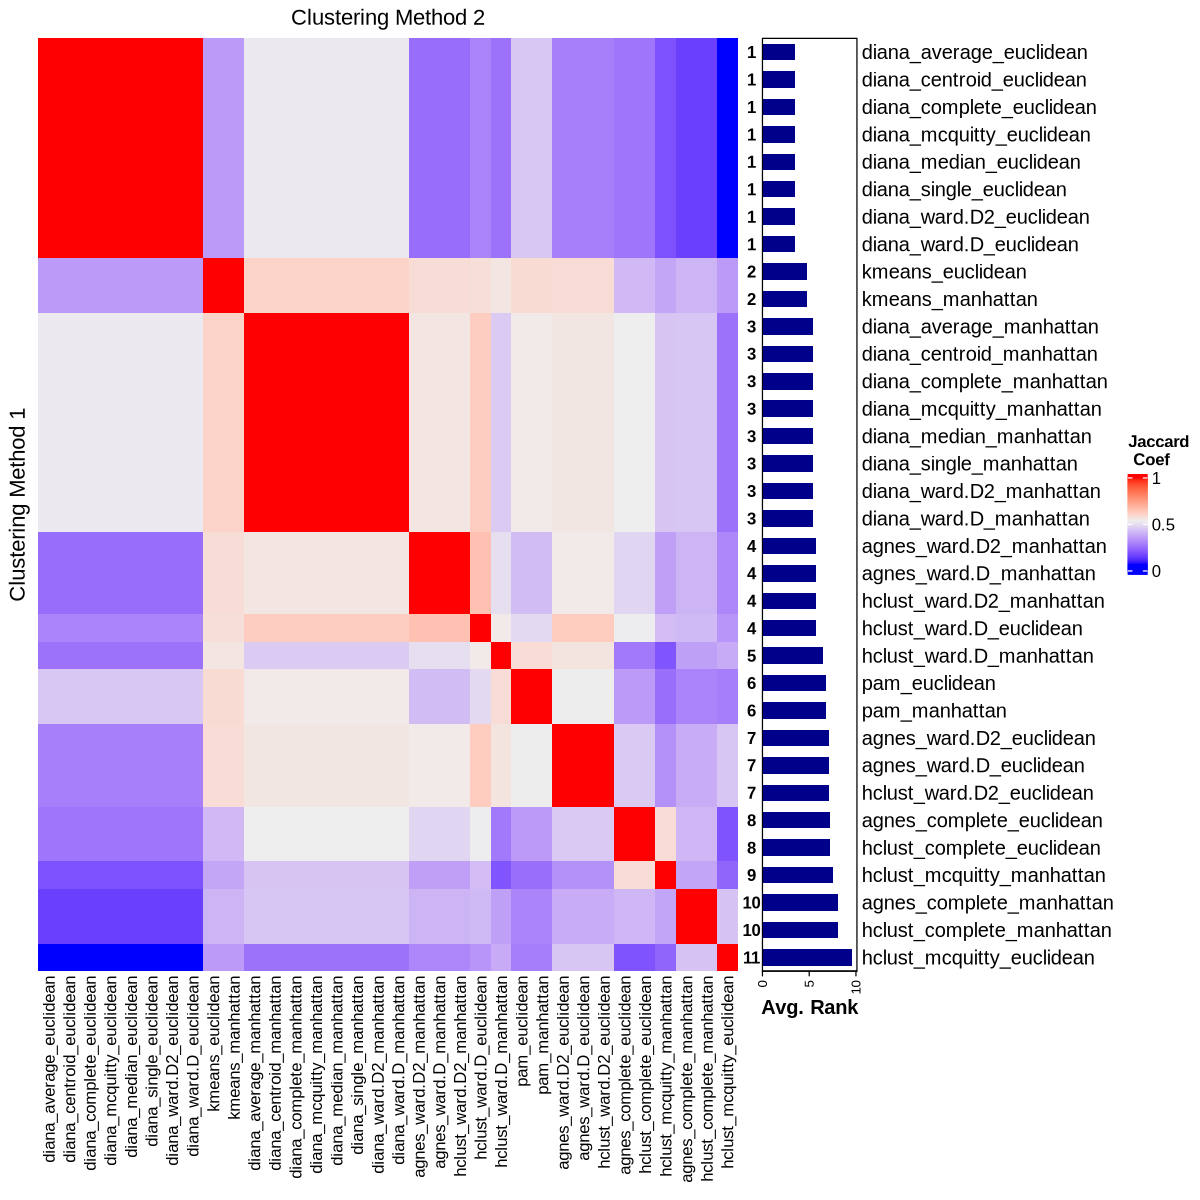

In [13]:
# Jaccard coefficient heatmap
options(repr.plot.width=16, repr.plot.height=10)

rank_colors <- colorRamp2(c(min(vector_rank, na.rm = TRUE), 
                            median(vector_rank, na.rm = TRUE), 
                            max(vector_rank, na.rm = TRUE)), 
                          c("blue", "white", "red"))

# Create an enhanced row annotation
row_anno <- rowAnnotation(
  "Best Rank" = anno_text(top_rank,
                          gp = gpar(fontsize = 10, fontface = "bold"),  # Improve annotation text style
                          location = unit(0.5, "npc"),  # Adjust text position
                          just = c("center", "center")),  # Center the text
  "Avg. Rank" = anno_barplot(vector_rank, 
                             gp = gpar(fill = "darkblue", col = NA),  # Bar color
                             width = unit(2, "cm")),  # Adjust width of annotation
  col = list("Avg. Rank" = rank_colors),  # Apply color scale
  annotation_name_gp = gpar(fontsize = 12, fontface = "bold"),  # Improve annotation title style
  annotation_legend_param = list(title = "Avg. Rank")  # Customize legend title
)

options(repr.plot.width=10, repr.plot.height=10)
# Create the heatmap for proportions with rankings as annotations
matching_heatmap_plot <- Heatmap(jaccard_index_matrix,
        name = "Jaccard\n Coef",  # Heatmap color bar label
        row_title = "Clustering Method 1",  # Title for row axis
        column_title = "Clustering Method 2",  # Title for column axis
        show_row_names = TRUE,  # Show row names (clusters)
        show_column_names = TRUE,  # Show column names (clusters)
        column_names_gp = gpar(fontsize = 10),  # Adjust font size for column names
        row_names_gp = gpar(fontsize = 12),  # Adjust font size for row names
        cluster_rows = FALSE,  # Cluster rows
        cluster_columns = FALSE,  # Cluster columns
        right_annotation = row_anno
  )
# Save plot
pdf(paste0(output_path, "matching_heatmap_plot.pdf"), width = 10, height = 10)  # adjust width/height as needed
draw(matching_heatmap_plot)
dev.off()
matching_heatmap_plot

## Cluster and UMAP

In [14]:
# Compute the UMAP and prepare the data for plotting
umap_model <- umap(procrutes_residuals, n_components = 2, random_state = 15)
umap_model <- as.data.frame(umap_model$layout)
colnames(umap_model) <- c("UMAP1", "UMAP2")
# Prepare the data for plotting
umap_cluster_data <- cbind(df_cluster_mapped[, order_cluster_method], umap_model) %>%
  pivot_longer(cols =  all_of(as.vector(order_cluster_method)), names_to = "method", values_to = "cluster") %>%
  mutate(method = factor(method, levels = order_cluster_method))

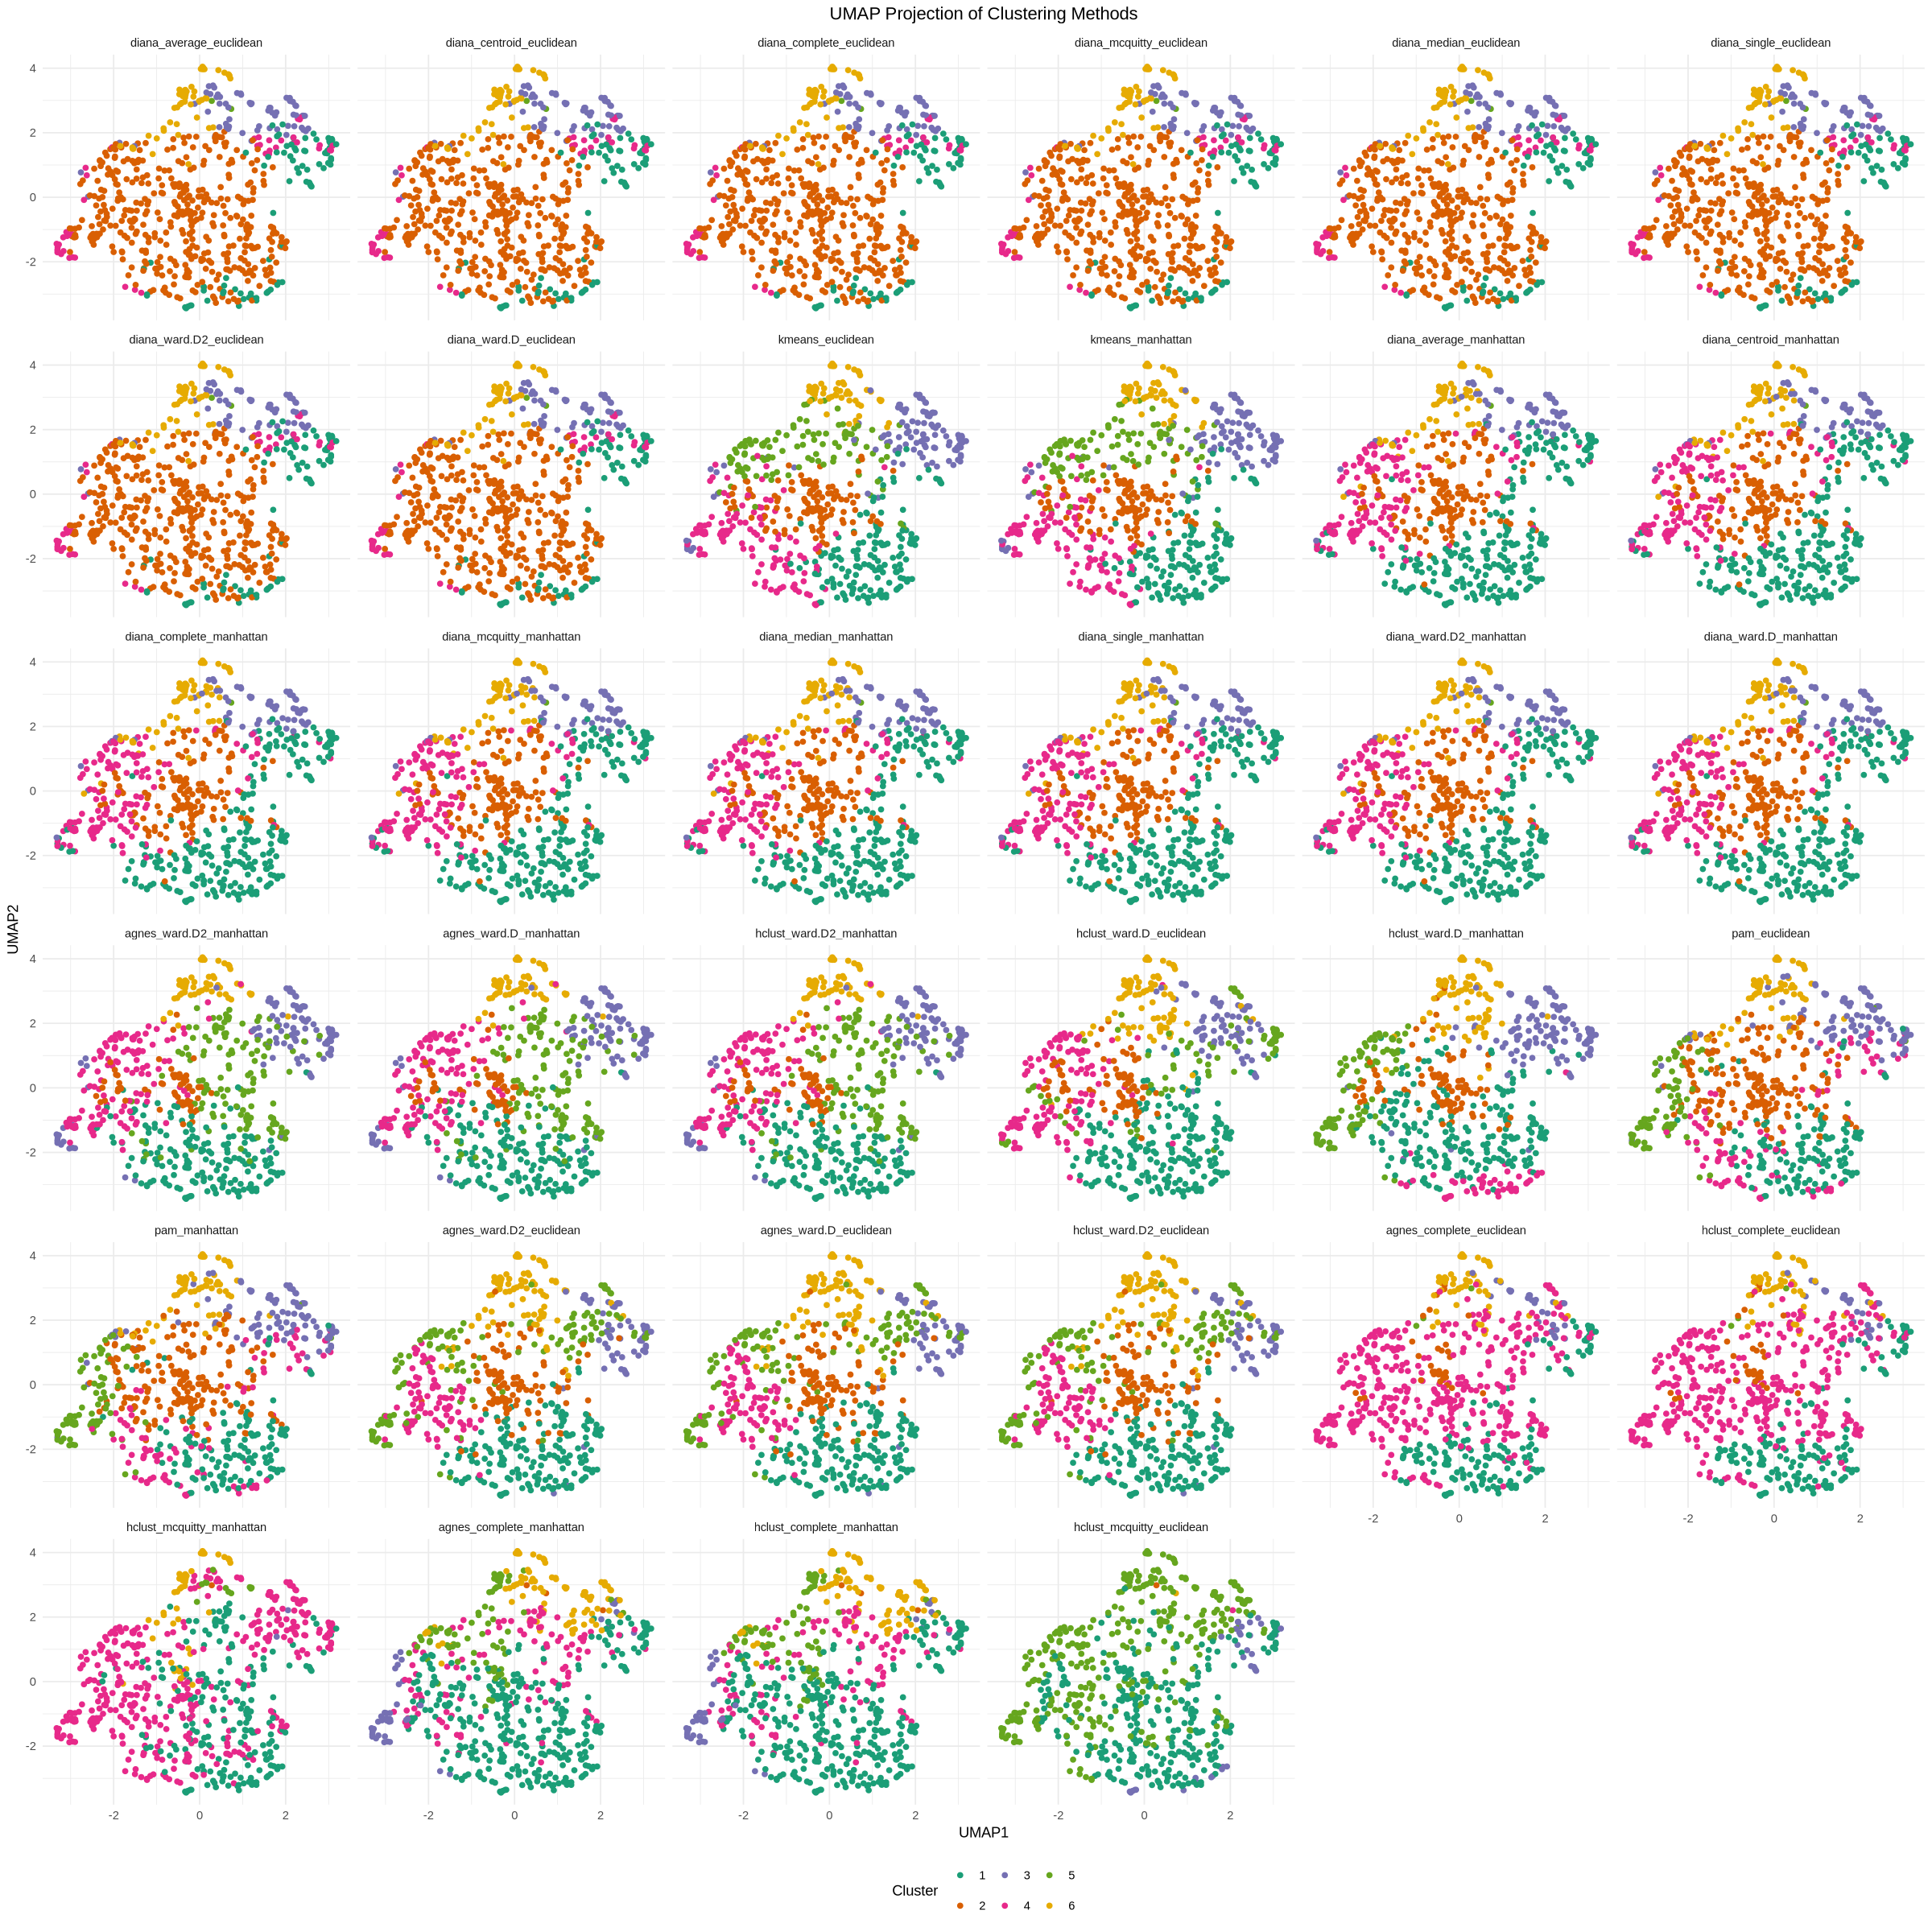

In [15]:
options(repr.plot.width = 20, repr.plot.height = 20)

# Create the plot
umap_cluster_plot <- ggplot(umap_cluster_data, aes(x = UMAP1, y = UMAP2, color = factor(cluster))) +
  geom_point() +
  facet_wrap(~ method, ncol = 6) +
  theme_minimal() +
  scale_color_manual(values = cluster_palette) +
  labs(title = "UMAP Projection of Clustering Methods", color = "Cluster") +
  theme(legend.position = "bottom") +
  theme(plot.title = element_text(hjust = 0.5))

# Save the plot
ggsave(paste0(output_path, "umap_cluster_plot.pdf"), plot = umap_cluster_plot, width = 20, height = 20, dpi = 300)
umap_cluster_plot

## Cluster Count Distribution

`summarise()` has grouped output by 'method'. You can override using the
`.groups` argument.


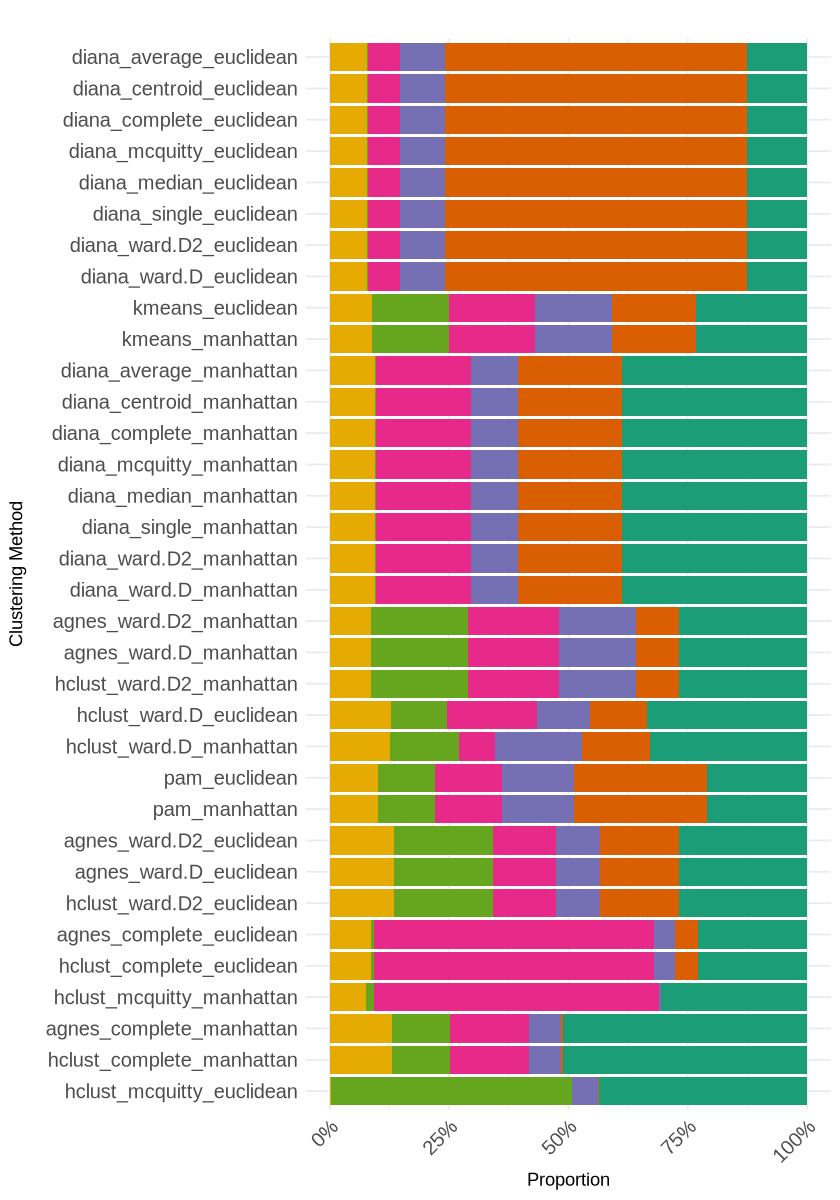

In [16]:
options(repr.plot.width = 7, repr.plot.height = 10)
cluster_matching_bar_plot <- df_cluster_mapped[, as.vector(order_cluster_method)] %>%
  pivot_longer(cols = as.vector(order_cluster_method), names_to = "method", values_to = "cluster") %>%
  group_by(method, cluster) %>%
  summarise(n = n()) %>%
  ungroup() %>%
  mutate(method = factor(method, levels = rev(as.vector(order_cluster_method)))) %>%
  ggplot(aes(x = method, y = n, fill = factor(cluster))) +
  geom_bar(stat = "identity", position = "fill") +
  scale_fill_manual(values = cluster_palette) +
  labs(title = "", x = "Clustering Method", y = "Proportion") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size=12)) +
  theme(axis.text.y = element_text( hjust = 1, size=12)) +
  theme(plot.title = element_text(hjust = 0.5)) +
  theme(legend.position = "rigth") +
  scale_y_continuous(labels = scales::percent_format(scale = 100)) +
  guides(fill = guide_legend(title = "Cluster")) +
  coord_flip()

ggsave(paste0(output_path, "proportions_clusters.pdf"), plot = cluster_matching_bar_plot, width = 7, height = 10, dpi = 300)
cluster_matching_bar_plot

## Advanced Clustering methods

Advanced clustering methods didn't provide effective clusters. 

### Gaussian mixture

In [17]:
# Gaussian Mixture Model (GMM) clustering
library(ClusterR)
GMM(procrutes_residuals, dist_mode = "eucl_dist")

GMM Cluster
 Call: GMM(data = procrutes_residuals, dist_mode = "eucl_dist") 
 Data cols: 24 
 Centroids: 1 

GM divides data into one cluster. Not an interesting result.

### DBSCAN

In [18]:
#which eps and min_pts to choose for DBSCAN: that give a reasonable number of clusters (2-9)
#none-scaled data
set.seed(123)
for (eps in seq(0, 0.5, 0.05)) {
  for (min_pts in seq(1, 15, 1)) {
    db <- dbscan(procrutes_residuals, eps = eps, MinPts = min_pts)
    k <- length(unique(db$cluster))
    if (k > 1 & k < 10){
        print(paste0('k: ', k, '; eps: ', eps,'; min_pts: ', min_pts))
        print(table(db$cluster))
    }
  }
}

[1] "k: 5; eps: 0.05; min_pts: 2"

  0   1   2   3   4 
647   2   2   2   2 
[1] "k: 5; eps: 0.1; min_pts: 2"

  0   1   2   3   4 
647   2   2   2   2 
[1] "k: 5; eps: 0.15; min_pts: 2"

  0   1   2   3   4 
647   2   2   2   2 
[1] "k: 5; eps: 0.2; min_pts: 2"

  0   1   2   3   4 
647   2   2   2   2 
[1] "k: 5; eps: 0.25; min_pts: 2"

  0   1   2   3   4 
647   2   2   2   2 
[1] "k: 5; eps: 0.3; min_pts: 2"

  0   1   2   3   4 
647   2   2   2   2 
[1] "k: 5; eps: 0.35; min_pts: 2"

  0   1   2   3   4 
647   2   2   2   2 
[1] "k: 5; eps: 0.4; min_pts: 2"

  0   1   2   3   4 
647   2   2   2   2 
[1] "k: 5; eps: 0.45; min_pts: 2"

  0   1   2   3   4 
647   2   2   2   2 
[1] "k: 5; eps: 0.5; min_pts: 2"

  0   1   2   3   4 
647   2   2   2   2 


DBSCAN selects automatically the number of clusters, and for several DBSCAN parameters the cluster solution is not relevant for our application (a single cluster has most of the patients).